In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [10]:
import pandas as pd
import torch

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_df = pd.read_csv(
    "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv"
)

x_train = train_df.iloc[:,1:].values
x_test = test_df.iloc[:,1:].values

x_train = torch.tensor(
    x_train,
    dtype=torch.float32
) / 255.0

x_test = torch.tensor(
    x_test,
    dtype=torch.float32
) / 255.0

x_train = x_train.view(-1,1,28,28)
x_test = x_test.view(-1,1,28,28)

train_dataset = TensorDataset(
    x_train,
    x_train
)

test_dataset = TensorDataset(
    x_test,
    x_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print(x_train.shape)
print(x_test.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])


In [29]:
import torch.nn as nn

LATENT_DIM = 32

class Autoencoder(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x.view(-1, 1, 28, 28)

In [30]:
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = Autoencoder(LATENT_DIM).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(device)

cpu


In [31]:
epochs = 10

losses = []

for epoch in range(epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | Loss = {epoch_loss:.6f}"
    )

Epoch 1/10 | Loss = 0.031070
Epoch 2/10 | Loss = 0.016452
Epoch 3/10 | Loss = 0.014085
Epoch 4/10 | Loss = 0.012653
Epoch 5/10 | Loss = 0.011737
Epoch 6/10 | Loss = 0.011094
Epoch 7/10 | Loss = 0.010575
Epoch 8/10 | Loss = 0.010214
Epoch 9/10 | Loss = 0.009941
Epoch 10/10 | Loss = 0.009693


 Grafik Loss

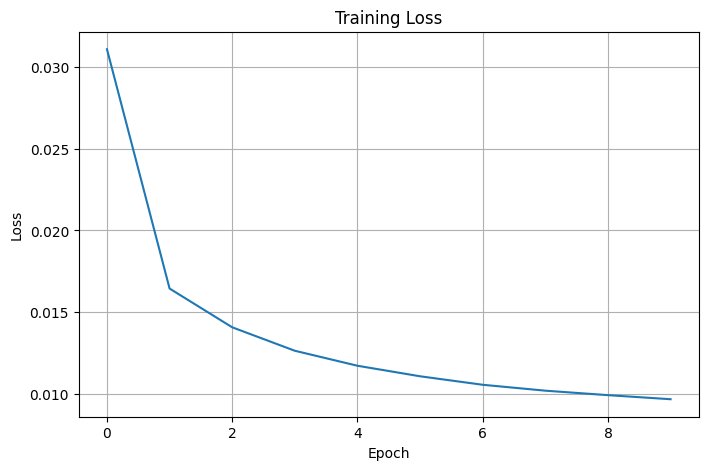

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

Rekonstruksi Gambar

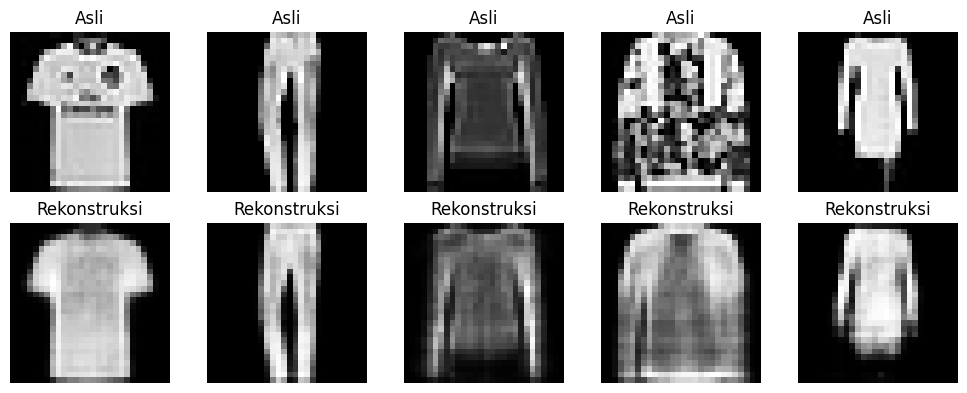

In [33]:
model.eval()

images, _ = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

fig, axes = plt.subplots(2,5, figsize=(10,4))

for i in range(5):

    axes[0,i].imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0,i].axis("off")

    axes[0,i].set_title("Asli")

    axes[1,i].imshow(
        reconstructed[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1,i].axis("off")

    axes[1,i].set_title("Rekonstruksi")

plt.tight_layout()
plt.show()

In [36]:
torch.save(
    model.state_dict(),
    "autoencoder_32.pth"
)

In [37]:
import os

print(os.listdir("/kaggle/working"))

['autoencoder_32.pth', '.virtual_documents', 'autoencoder_2.pth', 'autoencoder_8.pth']
